In [45]:
import pandas as pd
import numpy as np
import plotly.express as px
import shap

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

from xgboost import XGBRegressor

ROOT = Path.cwd().parent
print(ROOT)

c:\Users\sebas\PycharmProjects\Git\Indiana-Jones-and-the-Domestic-Box-Office-Forecasting-Model


In [3]:
model_df = pd.read_csv(
    ROOT/"data/processed/the_numbers_model_base_v1.csv"
)

print(model_df.shape)
model_df.head()

(2255, 30)


,tconst,primaryTitle,startYear,the_numbers_url,scrape_success,scrape_error,opening_weekend_gross,opening_theaters,domestic_release_date,release_type,...,source,production_method,creative_type,production_countries,languages,legs,plot_point,raw_opening_weekend_text,raw_theater_counts_text,raw_domestic_releases_text
0,tt0120667,Fantastic Four,2005.0,https://www.the-numbers.com/movie/Fantastic-Fo...,True,NaN,56061504.0,3602.0,2005-07-08,Wide,...,Based on Comic/Graphic Novel,Live Action,Super Hero,United States,English,2.76,"Friends turned Enemies, Origin Story, Revenge","$56,061,504 (36.2% of total gross)","3,602 opening theaters/3,619 max. theaters, 5....","July 8th, 2005 (Wide) by 20th Century Fox"
1,tt0121164,Corpse Bride,2005.0,https://www.the-numbers.com/movie/Corpse-Bride,True,NaN,19145480.0,3204.0,2005-09-16,Expands Wide,...,Based on Folk Tale/Legend/Fairytale,Stop-Motion Animation,Fantasy,United States,English,2.85,"Arranged Marriage, Friendly Ghost, Romance, Zo...","$19,145,480 (35.1% of total gross)","3,204 opening theaters/3,204 max. theaters, 5....","September 16th, 2005 (Special Engagement) by W..."
2,tt0121766,Star Wars: Episode III - Revenge of the Sith,2005.0,https://www.the-numbers.com/movie/Star-Wars-Ep...,True,NaN,108435841.0,3661.0,2005-05-19,Wide,...,Original Screenplay,Animation/Live Action,Science Fiction,United States,English,3.82,"Betrayal, Cloning, Cyborg, Death of a Spouse o...","$108,435,841 (26.2% of total gross)","3,661 opening theaters/3,663 max. theaters, 8....","May 19th, 2005 (Wide) by 20th Century Fox Apri..."
3,tt0167190,Hellboy,2004.0,https://www.the-numbers.com/movie/Hellboy,True,NaN,23172440.0,3028.0,2004-04-02,Wide,...,Based on Comic/Graphic Novel,Live Action,Super Hero,United States,English,2.57,Demons Source material: Dark Horse Comics,"$23,172,440 (38.9% of total gross)","3,028 opening theaters/3,043 max. theaters, 4....","April 2nd, 2004 (Wide) by Sony Pictures"
4,tt0200465,The Bank Job,2008.0,https://www.the-numbers.com/movie/Bank-Job-The,True,NaN,5935256.0,1603.0,2008-03-07,Wide,...,Based on Real Life Events,Live Action,Dramatization,United Kingdom,English,5.06,"Bank Robbery, Blackmail, Corrupt Cops, Heist, ...","$5,935,256 (19.7% of total gross)","1,603 opening theaters/1,613 max. theaters, 6....","March 7th, 2008 (Wide) by Lionsgate"


In [4]:
model_df["domestic_release_date"] = pd.to_datetime(
    model_df["domestic_release_date"],
    errors="coerce"
)

model_df = model_df[
    model_df["opening_weekend_gross"].notna()
].copy()

model_df["log_opening_weekend_gross"] = np.log1p(
    model_df["opening_weekend_gross"]
)

model_df["release_month"] = model_df["domestic_release_date"].dt.month
model_df["release_day_of_year"] = model_df["domestic_release_date"].dt.dayofyear

In [37]:
target = "legs"

numeric_features = [
    # "opening_theaters",
    "production_budget",
    "runtime_minutes",
    "release_month",
    "release_day_of_year",
]

categorical_features = [
    # "release_type",
    "distributor",
    "MPA_rating",
    "genre",
    "subgenre",
    "source",
    "production_method",
    "creative_type",
    "production_countries",
    "languages",
]

In [38]:
feature_cols = numeric_features + categorical_features

model_data = model_df[
    feature_cols + [target, "opening_weekend_gross"]
].copy()

X = model_data[feature_cols]
y = model_data[target]

print(X.shape)
print(y.shape)

(2255, 13)
(2255,)


In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [40]:
y_test_dollars = np.expm1(y_test)

In [41]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [42]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    pred_log = model.predict(X_test)

    r2_log = r2_score(y_test, pred_log)
    mae_log = mean_absolute_error(y_test, pred_log)

    pred_dollars = np.expm1(pred_log)

    mae_dollars = mean_absolute_error(y_test_dollars, pred_dollars)

    results = {
        "model": name,
        "r2_log": r2_log,
        "mae_log": mae_log,
        "mae_dollars": mae_dollars
    }

    return results, pred_log, pred_dollars

In [43]:
ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_results, ridge_pred_log, ridge_pred_dollars = evaluate_model(
    "Ridge Baseline",
    ridge_model,
    X_train,
    X_test,
    y_train,
    y_test
)

ridge_results

{'model': 'Ridge Baseline',
 'r2_log': 0.11916999876949108,
 'mae_log': 1.1735852020068316,
 'mae_dollars': 4.897550340787184e+27}

In [44]:
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    ))
])

xgb_results, xgb_pred_log, xgb_pred_dollars = evaluate_model(
    "XGBoost Baseline",
    xgb_model,
    X_train,
    X_test,
    y_train,
    y_test
)

xgb_results

{'model': 'XGBoost Baseline',
 'r2_log': 0.26222099307322566,
 'mae_log': 1.0279814519268975,
 'mae_dollars': 4.897550340787184e+27}

In [33]:
results_df = pd.DataFrame([
    ridge_results,
    xgb_results
])

results_df

,model,r2_log,mae_log,mae_dollars
0,Ridge Baseline,0.542268,0.865227,1.582174e+07
1,XGBoost Baseline,0.583036,0.802680,1.346234e+07


In [34]:
plot_df = pd.DataFrame({
    "actual": y_test_dollars,
    "predicted": xgb_pred_dollars
})

fig = px.scatter(
    plot_df,
    x="actual",
    y="predicted",
    title="XGBoost Baseline: Actual vs Predicted",
    opacity=0.6
)

fig.add_shape(
    type="line",
    x0=plot_df["actual"].min(),
    y0=plot_df["actual"].min(),
    x1=plot_df["actual"].max(),
    y1=plot_df["actual"].max(),
)

fig.show()

In [ ]:
X_train_transformed = (
    xgb_model.named_steps["preprocessor"]
    .transform(X_train)
)

X_test_transformed = (
    xgb_model.named_steps["preprocessor"]
    .transform(X_test)
)

feature_names = (
    xgb_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

trained_xgb = xgb_model.named_steps["model"]

In [48]:
explainer = shap.TreeExplainer(trained_xgb)

X_shap = X_test_transformed[:500]

shap_values = explainer.shap_values(X_shap)

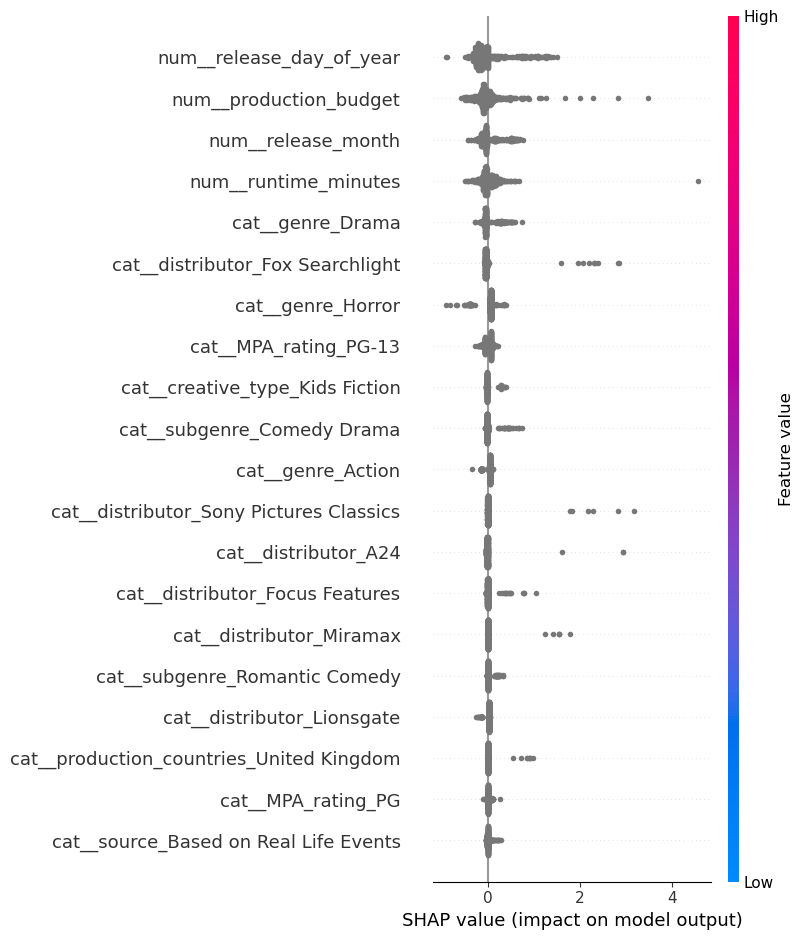

In [49]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names
)

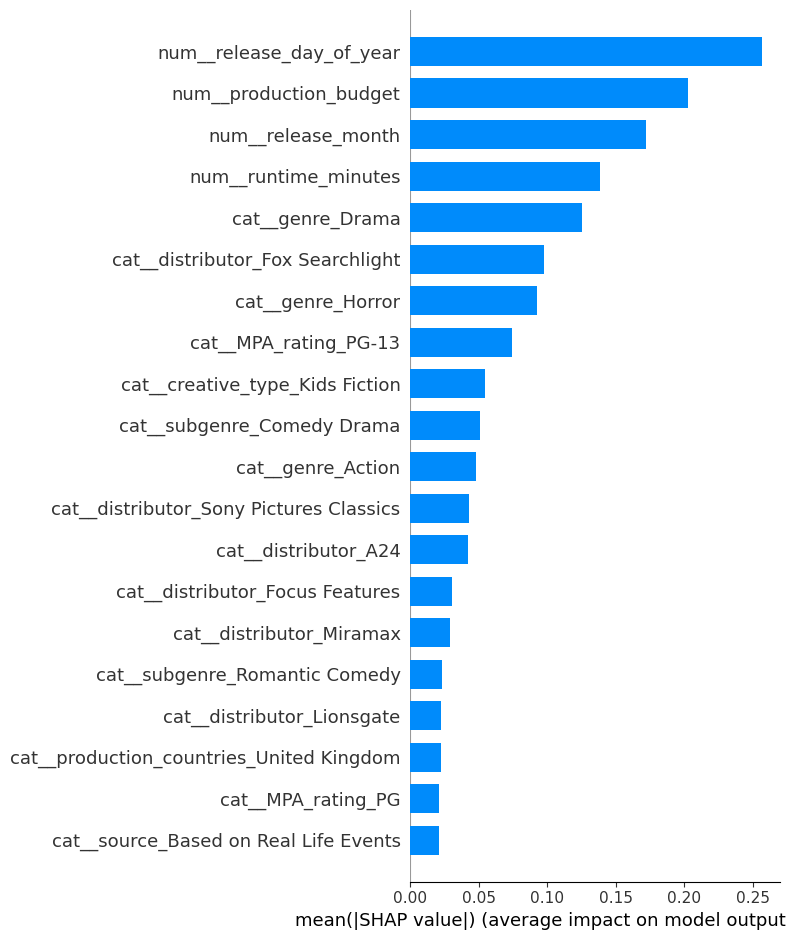

In [50]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    plot_type="bar"
)

## Notes on Feature Leakage, Forecasting Stages, and Modeling Tiers

During baseline modeling, opening theater count dramatically increased model performance:

- XGBoost without `opening_theaters` and `release_type`
  - R² ≈ 0.58

- XGBoost with `opening_theaters` and `release_type`
  - R² ≈ 0.90

This suggests that theater count and release strategy encode substantial downstream market information.

Although `opening_theaters` exists before opening weekend numerically, it is not an intrinsic movie attribute. Theater count is likely influenced by many hidden industry forecasting signals, including:

- trailer engagement
- social media hype
- advance ticket sales
- franchise familiarity
- tracking surveys
- marketing expectations
- exhibitor confidence
- critic expectations

Similarly, `release_type` (Wide, Limited, Expands Wide) likely reflects studio confidence and rollout strategy decisions informed by expected demand.

This creates an important distinction between:
- intrinsic movie characteristics
- market/distribution confidence signals

Rather than treating all features equally, the project may be better framed as a series of forecasting stages.

---

## Proposed Modeling Tiers

### Tier 1 — Intrinsic Metadata Model
Attempts to predict opening weekend using mostly intrinsic or structural movie characteristics.

Potential features:
- genre
- subgenre
- source material
- creative type
- production method
- runtime
- MPA rating
- production budget
- cast/director features
- engineered semantic features

Excludes:
- opening theater count
- release type

Goal:
Estimate how predictable audience demand is from movie characteristics alone.

---

### Tier 2 — Pre-Release Market Information Model
Adds real-world market-facing information that is publicly known before release.

Additional features:
- distributor
- release date/month/seasonality
- competition density
- Google Trends
- social media metrics
- trailer engagement

Goal:
Estimate how much additional predictive power comes from observable market positioning and audience awareness.

---

### Tier 3 — Distribution Strategy Model
Adds studio deployment and rollout decisions.

Additional features:
- opening theater count
- release type

Goal:
Estimate opening weekend after incorporating the industry's own distribution confidence signals.

This tier likely reflects not only movie quality or audience demand, but also the forecasting ability of studios and exhibitors themselves.

In [35]:
error_df = X_test.copy()

error_df["actual_log"] = y_test
error_df["pred_log"] = xgb_pred_log

error_df["actual_opening_weekend"] = np.expm1(y_test)
error_df["pred_opening_weekend"] = xgb_pred_dollars

error_df["abs_error"] = (
    error_df["actual_opening_weekend"] -
    error_df["pred_opening_weekend"]
).abs()

error_df.sort_values("abs_error", ascending=False).head(20)

,production_budget,runtime_minutes,release_month,release_day_of_year,distributor,MPA_rating,genre,subgenre,source,production_method,creative_type,production_countries,languages,actual_log,pred_log,actual_opening_weekend,pred_opening_weekend,abs_error
1926,400000000.0,181.0,4,116,Walt Disney,PG-13,Action,Action Adventure,Based on Comic/Graphic Novel,Animation/Live Action,Super Hero,United States,English,19.693568,18.751020,357115007.0,139144064.0,217970943.0
900,200000000.0,148.0,12,351,Sony Pictures,PG-13,Action,Action Adventure,Based on Comic/Graphic Novel,Animation/Live Action,Super Hero,United States,English,19.376725,18.128227,260138569.0,74642992.0,185495577.0
174,215000000.0,124.0,6,163,Universal,PG-13,Action,Action Adventure,Based on Fiction Book/Short Story,Live Action,Science Fiction,United States,English,19.156917,18.108606,208806270.0,73192704.0,135613566.0
1469,200000000.0,120.0,2,47,Walt Disney,PG-13,Action,Action Adventure,Based on Comic/Graphic Novel,Live Action,Super Hero,United States,English,19.123798,18.086065,202003951.0,71561320.0,130442631.0
1271,145000000.0,114.0,7,202,Warner Bros.,PG-13,Comedy,Satirical Comedy,Based on Toy,Live Action,Contemporary Fiction,United States,English,18.903243,17.497498,162022044.0,39725248.0,122296796.0
1207,58000000.0,107.0,2,43,20th Century Fox,R,Action,Action Comedy,Spin-Off,Animation/Live Action,Super Hero,United States,English,18.701600,16.822536,132434639.0,20227152.0,112207487.0
997,160000000.0,123.0,3,76,Walt Disney,PG,Musical,Family Musical,Based on Folk Tale/Legend/Fairytale,Animation/Live Action,Fantasy,United States,English,18.978870,18.010685,174750616.0,66365304.0,108385312.0
1151,150000000.0,100.0,11,332,Walt Disney,PG,Musical,Musical-Adventure,Original Screenplay,Digital Animation,Kids Fiction,United States,English,18.755633,17.330959,139787385.0,33631016.0,106156369.0
1402,136200000.0,115.0,11,321,Lionsgate,PG-13,Drama,Romantic Drama,Based on Fiction Book/Short Story,Live Action,Fantasy,United States,English,18.764750,17.439795,141067634.0,37497864.0,103569770.0
529,185000000.0,152.0,7,200,Warner Bros.,PG-13,Action,Action Thriller,Based on Comic/Graphic Novel,Live Action,Super Hero,United States,"English, Mandarin",18.880707,17.937706,158411483.0,61694540.0,96716943.0


In [36]:
results_df.to_csv(
    ROOT/"data/processed/baseline_model_results.csv",
    index=False
)

error_df.to_csv(
    ROOT/"data/processed/baseline_xgb_test_errors.csv",
    index=False
)